## Exercise: Rock-Paper-Scissors Equilibrium
From the paper "An Introduction to Counterfactual Regret Minimization" by Todd W. Neller and Marc Lanctot, Section 2.5.

In [1]:
import numpy as np

np.random.seed(2)  # For reproducibility

In [2]:
# init action values for the actions
ROCK = 0
PAPER = 1
SCISSORS = 2

# number of actions in RPS
NUM_ACTIONS = 3
payoff = np.array([
    [ 0, -1,  1],
    [ 1,  0, -1],
    [-1,  1,  0],
])

In [3]:
def get_strategy(regret_sum, strategy_sum):
    """Get the current strategy based on regret matching."""
    strategy = np.maximum(regret_sum, 0)
    normalizing_sum = strategy.sum()

    if normalizing_sum > 0:
        strategy = strategy / normalizing_sum
    else:
        strategy = np.ones(NUM_ACTIONS) / NUM_ACTIONS

    strategy_sum += strategy
    return strategy

In [4]:
def get_action(strategy):
    """Get an action based on the current strategy."""
    r = np.random.random()
    cumulative_probability = 0.0
    
    for a in range(NUM_ACTIONS):
        cumulative_probability += strategy[a]
        if r < cumulative_probability:
            return a
    return NUM_ACTIONS - 1  # fallback to last action

In [5]:
def get_average_strategy(strategy_sum):
    total = strategy_sum.sum()
    return strategy_sum / total if total > 0 else np.ones(NUM_ACTIONS) / NUM_ACTIONS

In [6]:
def train_two_player(iterations, log_every=1_000):
    regret_sum_p1 = np.zeros(NUM_ACTIONS)
    strategy_sum_p1 = np.zeros(NUM_ACTIONS)
    regret_sum_p2 = np.zeros(NUM_ACTIONS)
    strategy_sum_p2 = np.zeros(NUM_ACTIONS)

    history_p1, history_p2 = [], []
    
    for i in range(iterations):
        strat1 = get_strategy(regret_sum_p1, strategy_sum_p1)
        strat2 = get_strategy(regret_sum_p2, strategy_sum_p2)

        a1 = get_action(strat1)
        a2 = get_action(strat2)

        util1 = payoff[:, a2]       # p1's utility for each action, given p2 played a2
        util2 = -payoff[a1, :]      # p2's utility for each action, given p1 played a1

        regret_sum_p1 += util1 - util1[a1]
        regret_sum_p2 += util2 - util2[a2]

        if i % log_every == 0:
            history_p1.append((strategy_sum_p1 / max(strategy_sum_p1.sum(), 1e-12)).copy())
            history_p2.append((strategy_sum_p2 / max(strategy_sum_p2.sum(), 1e-12)).copy())

    return np.array(history_p1), np.array(history_p2)

In [7]:
steps = 5_000
h1, h2 = train_two_player(1_000_000, log_every=steps)

## plotting

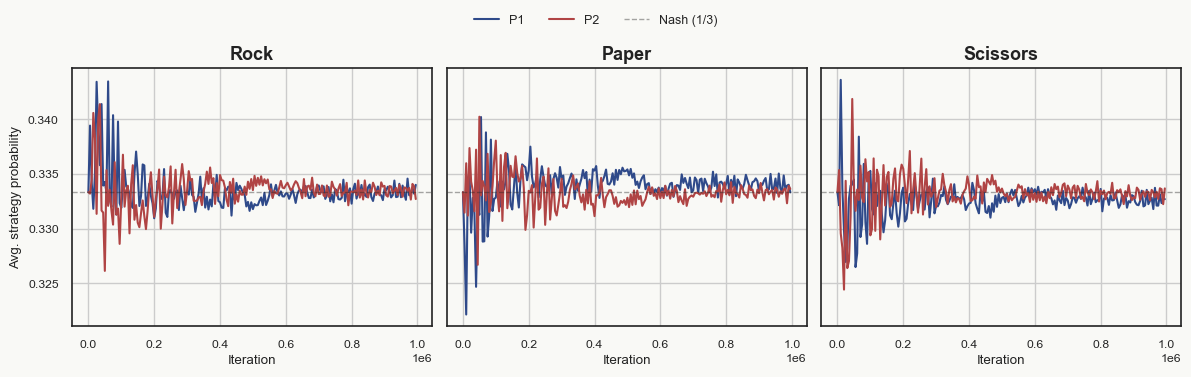

In [8]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

OFF_WHITE = "#F9F9F6"
INK = "#222222"
BLUE = "#2F4A8A"
RED = "#B04444"

sns.set_theme(
    style="whitegrid",
    font_scale=0.8,
    rc={'figure.facecolor': OFF_WHITE, 'axes.facecolor': OFF_WHITE}
)

labels = ["Rock", "Paper", "Scissors"]
iters = np.arange(len(h1)) * steps

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True, facecolor=OFF_WHITE)

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.set_facecolor(OFF_WHITE)
    ax.plot(iters, h1[:, i], color=BLUE, linewidth=1.5, label="P1")
    ax.plot(iters, h2[:, i], color=RED, linewidth=1.5, label="P2")
    ax.axhline(1/3, color=INK, linestyle="--", linewidth=1, alpha=0.4)
    ax.set_title(label, fontsize=13, fontweight="bold", color=INK)
    ax.set_xlabel("Iteration", color=INK)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color(INK)

axes[0].set_ylabel("Avg. strategy probability", color=INK)

p1_line = mlines.Line2D([], [], color=BLUE, linewidth=1.5, label="P1")
p2_line = mlines.Line2D([], [], color=RED, linewidth=1.5, label="P2")
nash_line = mlines.Line2D([], [], color=INK, linestyle="--", linewidth=1, alpha=0.4, label="Nash (1/3)")
fig.legend(handles=[p1_line, p2_line, nash_line], frameon=False, fontsize=9,
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()
plt.show()